In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [11]:
df = pd.read_csv('Sample - Superstore.csv',encoding='latin1')

In [12]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [13]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [15]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [16]:
df=df.drop_duplicates()

In [17]:
print("Total Row:",len(df))

Total Row: 9994


In [18]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [19]:
df['Order Date'].head()

,Order Date
0,2016-11-08
1,2016-11-08
2,2016-06-12
3,2015-10-11
4,2015-10-11


In [20]:
df['Year'] = df['Order Date'].dt.year

df['Month'] = df['Order Date'].dt.month

df['Day'] = df['Order Date'].dt.day

In [21]:
df[['Order Date', 'Year', 'Month', 'Day']].head()

,Order Date,Year,Month,Day
0,2016-11-08,2016,11,8
1,2016-11-08,2016,11,8
2,2016-06-12,2016,6,12
3,2015-10-11,2015,10,11
4,2015-10-11,2015,10,11


In [22]:
daily_sales = df.groupby('Order Date')['Sales'].sum().reset_index()

In [23]:
daily_sales.head()

,Order Date,Sales
0,2014-01-03,16.448
1,2014-01-04,288.060
2,2014-01-05,19.536
3,2014-01-06,4407.100
4,2014-01-07,87.158


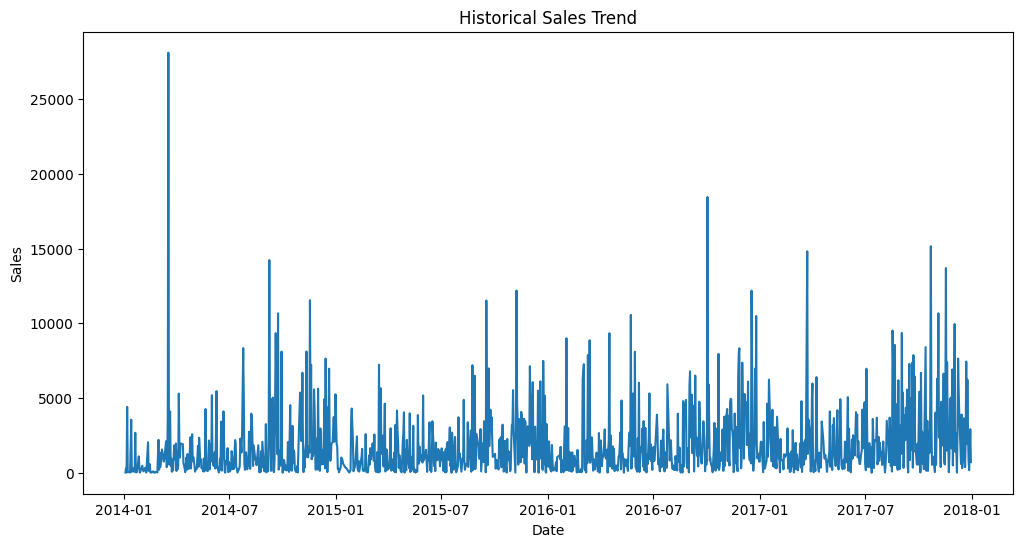

In [24]:
plt.figure(figsize=(12,6))

plt.plot(
    daily_sales['Order Date'],
    daily_sales['Sales']
)

plt.title('Historical Sales Trend')
plt.xlabel('Date')
plt.ylabel('Sales')

plt.show()

In [25]:
daily_sales['Day_Number'] = range(len(daily_sales))

In [26]:
daily_sales.head()

,Order Date,Sales,Day_Number
0,2014-01-03,16.448,0
1,2014-01-04,288.060,1
2,2014-01-05,19.536,2
3,2014-01-06,4407.100,3
4,2014-01-07,87.158,4


In [27]:
X = daily_sales[['Day_Number']]
y = daily_sales['Sales']

In [28]:
print(X.head())
print(y.head())

   Day_Number
0           0
1           1
2           2
3           3
4           4
0      16.448
1     288.060
2      19.536
3    4407.100
4      87.158
Name: Sales, dtype: float64


In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

In [30]:
print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 989
Testing rows: 248


In [31]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [32]:
print("Model trained successfully!")

Model trained successfully!


In [33]:
predictions = model.predict(X_test)

In [34]:
print(predictions[:5])

[2172.6897409  2173.61881159 2174.54788228 2175.47695297 2176.40602366]


In [35]:
mae = mean_absolute_error(y_test, predictions)

rmse = np.sqrt(mean_squared_error(y_test, predictions))

r2 = r2_score(y_test, predictions)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 1797.5054227377639
RMSE: 2453.4919203368595
R2: 0.010797653433313958


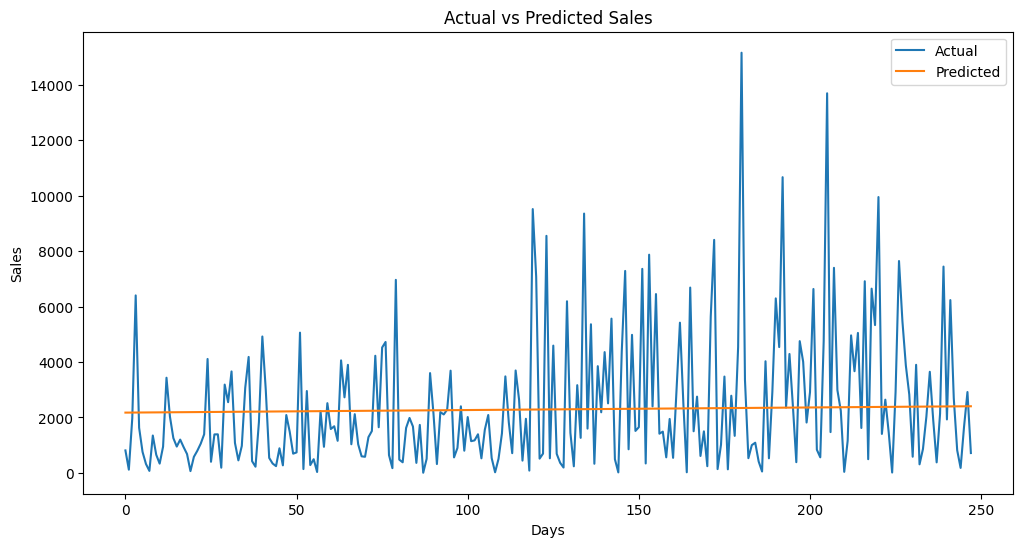

In [36]:
plt.figure(figsize=(12,6))

plt.plot(y_test.values, label='Actual')

plt.plot(predictions, label='Predicted')

plt.legend()

plt.title('Actual vs Predicted Sales')

plt.xlabel('Days')

plt.ylabel('Sales')

plt.show()

In [37]:
future_days = pd.DataFrame({
    'Day_Number': range(
        len(daily_sales),
        len(daily_sales) + 30
    )
})

In [38]:
future_days.head()

,Day_Number
0,1237
1,1238
2,1239
3,1240
4,1241


In [39]:
future_sales = model.predict(future_days)

In [40]:
print(future_sales[:5])

[2403.09927242 2404.02834312 2404.95741381 2405.8864845  2406.81555519]


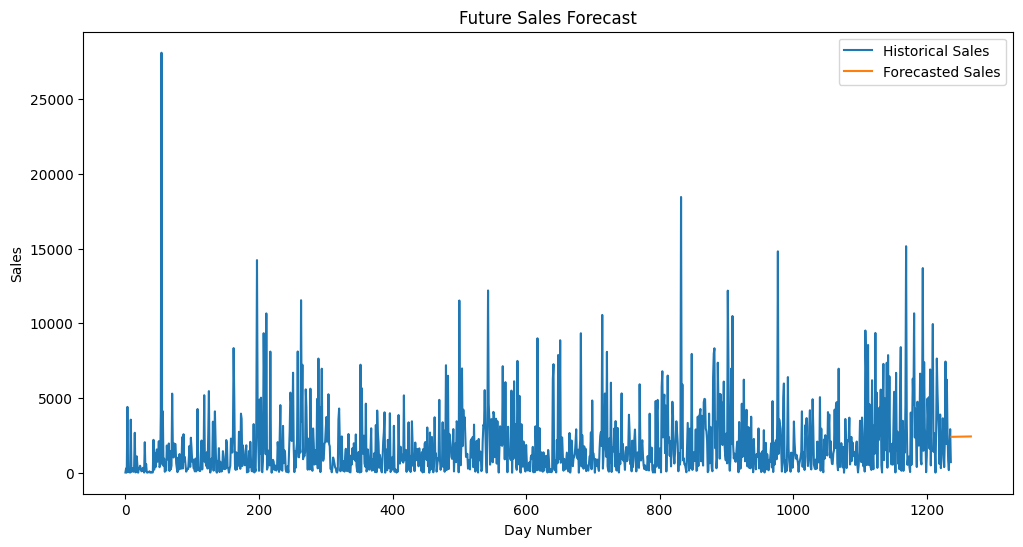

In [41]:
plt.figure(figsize=(12,6))

plt.plot(
    daily_sales['Day_Number'],
    daily_sales['Sales'],
    label='Historical Sales'
)

plt.plot(
    future_days['Day_Number'],
    future_sales,
    label='Forecasted Sales'
)

plt.title('Future Sales Forecast')

plt.xlabel('Day Number')

plt.ylabel('Sales')

plt.legend()

plt.show()